# Libraries and palettes

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex
import networkx as nx

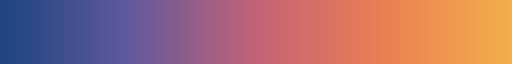

In [6]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')
sunset2

# Comprobations of RN Generation

mean: 1.702315638
std: 0    0.897682
dtype: float64
Theoretical mean: 1.7110914332847293
Theoretical std: 0.8944271909999159


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


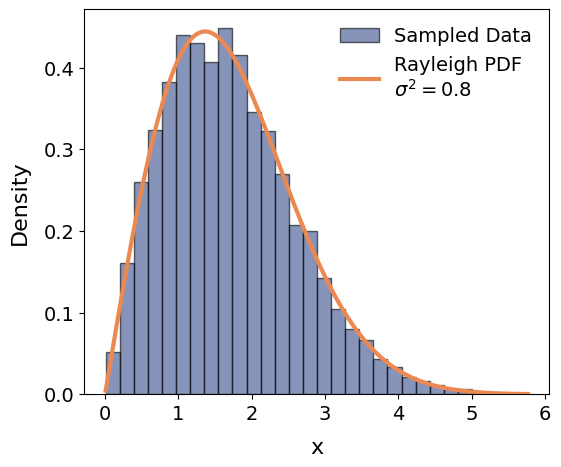

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pypalettes import load_cmap 
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

rayleigh_sample = pd.read_csv('test_rayleigh.txt', header = None)
print("mean:", np.mean(rayleigh_sample))
print("std:", np.std(rayleigh_sample))

# mean = 1.0;
# sigma = mean * np.sqrt(2.0 / np.pi);
variance = 0.8;
sigma = np.sqrt(variance*2/(4-np.pi))
mean = sigma * np.sqrt(np.pi / 2.0)
print('Theoretical mean:', mean)
print('Theoretical std:', np.sqrt((4 - np.pi) / 2.0 * sigma**2))
the_x = np.arange(np.min(rayleigh_sample), np.max(rayleigh_sample), 0.01)
the_y = (the_x / (sigma**2)) * np.exp(- (the_x**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(rayleigh_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Rayleigh PDF\n' r'$\sigma^2 = 0.8$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)


mean: 0.2953173248
std: 0    0.201887
dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(-1.2, 1.2)

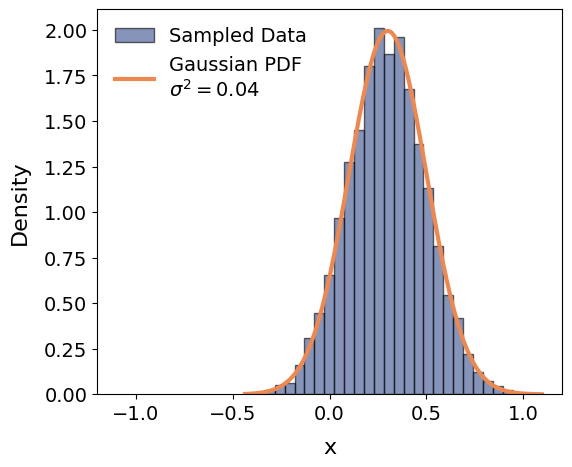

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pypalettes import load_cmap 
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

gaussian_sample = pd.read_csv('test_gaussian.txt', header = None)
print("mean:", np.mean(gaussian_sample))
print("std:", np.std(gaussian_sample))

mean = 0.3;
sigma = np.sqrt(0.04);
the_x = np.arange(np.min(gaussian_sample), np.max(gaussian_sample), 0.01)
the_y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(- ((the_x - mean)**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(gaussian_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Gaussian PDF\n' r'$\sigma^2 = 0.04$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)
plt.xlim(-1.2, 1.2)


# Neuronal network

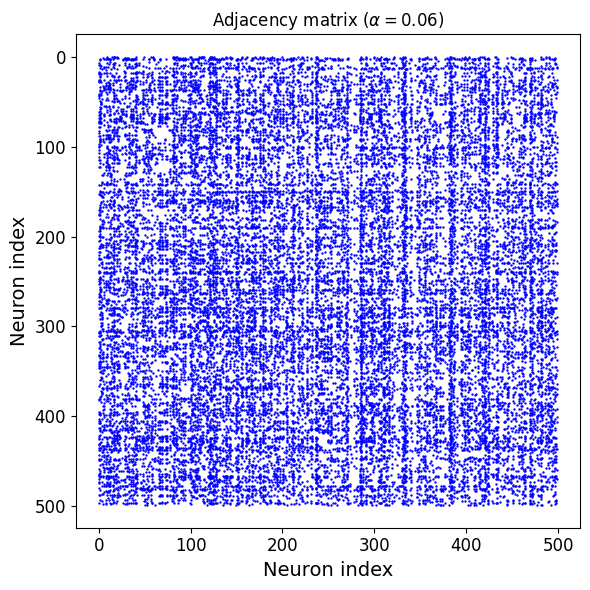

In [14]:
import numpy as np
import matplotlib.pyplot as plt

N = 500
file_adjacency_matrix = 'networks/adjacency_matrix_a0.0600.txt'

with open(file_adjacency_matrix, 'r') as f:
    lines = [line.strip() for line in f if line.strip()]

A = np.frombuffer("".join(lines).encode("ascii"), dtype=np.uint8) - ord('0')
A = A.reshape(N, N)
rows, cols = np.where(A == 1)
plt.figure(figsize=(6, 6))
plt.scatter(cols, rows, s=0.5, color='blue')
plt.gca().invert_yaxis()
plt.xlabel('Neuron index', fontsize=14)
plt.ylabel('Neuron index', fontsize=14)
plt.title(r'Adjacency matrix ($\alpha=0.06$)')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

import numpy as np

def read_adj_01txt(path, N=500):
    with open(path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    if len(lines) != N:
        raise ValueError(f"{path}: {len(lines)} líneas, esperado {N}")
    # convierte caracteres '0'/'1' a uint8
    A = np.frombuffer(("".join(lines)).encode("ascii"), dtype=np.uint8) - ord('0')
    return A.reshape(N, N)

alpha = np.arange(0, 0.99, 0.0010)
filenames = [f'networks/adjacency_matrix_a{a:.4f}.txt' for a in alpha]
filenames = [f for f in filenames if os.path.exists(f)]
degrees = []
stds = []

for file in filenames:
    A = read_adj_01txt(file, N=500)
    np.fill_diagonal(A, 0)
    deg = A.sum(axis=1)
    degrees.append(deg.mean())
    stds.append(deg.std())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pypalettes import load_cmap 
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

def gcs_bfs_undirected(A: np.ndarray) -> float:
    n = A.shape[0]
    U = (A | A.T).astype(bool)
    np.fill_diagonal(U, False)

    visited = np.zeros(n, dtype=bool)
    best = 0

    for start in range(n):
        if visited[start]:
            continue
        # BFS con "frontier"
        frontier = np.zeros(n, dtype=bool)
        frontier[start] = True
        visited[start] = True
        comp_size = 0

        while frontier.any():
            comp_size += frontier.sum()
            # vecinos de la frontera (OR de filas)
            neigh = U[frontier].any(axis=0)
            neigh &= ~visited
            visited |= neigh
            frontier = neigh

        if comp_size > best:
            best = comp_size

    return best / n

GCS = []
for file in filenames:
    A = read_adj_01txt(file, N=500)
    gcs = gcs_bfs_undirected(A)
    GCS.append(gcs)

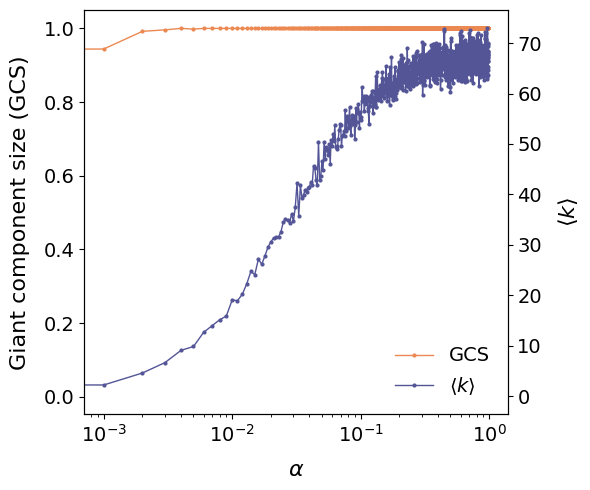

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pypalettes import load_cmap 
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

fig, ax1 = plt.subplots(figsize=(6,5))

# Eje izquierdo: GCS
ax1.plot(
    alpha, GCS,
    marker='o', markersize=2, linestyle='-',lw = 1,
    color=sunset2(0.8), label='GCS'
)
ax1.set_xlabel(r'$\alpha$', fontsize=16, labelpad=10)
ax1.set_ylabel('Giant component size (GCS)', fontsize=16, color='black', labelpad=10)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xscale('log')
ax1.tick_params(axis='both', labelsize=14)

# Eje derecho: grado medio
ax2 = ax1.twinx()
ax2.plot(
    alpha, degrees,
    marker='o', markersize=2, linestyle='-', lw = 1,
    color=sunset2(0.2), label=r'$\langle k\rangle$'
)
ax2.set_ylabel(r'$\langle k\rangle$', fontsize=16, color='black', labelpad=10)
ax2.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='both', labelsize=14)

# Opcional: leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=14, loc='lower right', frameon=False)

plt.tight_layout()
plt.show()


In [19]:
import os, numpy as np

path = "networks/adjacency_matrix_run011.bin"
size = os.path.getsize(path)
print("File size (bytes):", size)

with open(path, "rb") as f:
    N = np.fromfile(f, dtype=np.int32, count=1)[0]
    M = np.fromfile(f, dtype=np.int32, count=1)[0]
    alpha0 = np.fromfile(f, dtype=np.float64, count=1)[0]
    dalpha = np.fromfile(f, dtype=np.float64, count=1)[0]
    offset = f.tell()

print("N, M, alpha0, dalpha, offset:", N, M, alpha0, dalpha, offset)

expected = offset + int(M)*int(N)*int(N)  # uint8 => 1 byte por entrada
print("Expected size:", expected)
print("Matches:", expected == size)


File size (bytes): 249750024
N, M, alpha0, dalpha, offset: 500 1000 0.001 0.001 24
Expected size: 250000024
Matches: False


In [2]:
import os
import numpy as np

import os, numpy as np, warnings

# Esta función carga un archivo binario que contiene matrices de adyacencia
# (probablemente guardadas como uint8, es decir, 0/1).
# Está diseñada para ser "segura": detecta archivos truncados,
# inconsistencias en el header, etc.
def load_run_bin_safe(path, allow_truncate=True):
    try:
        # obtiene el tamaño total del archivo en bytes
        size = os.path.getsize(path)

        # abrimos el archivo en modo binario para leer el header
        with open(path, "rb") as f:

            # N -> tamaño de la red (matriz NxN)
            N = np.fromfile(f, np.int32, 1)[0]

            # M_hdr -> número de matrices que el header dice que hay
            M_hdr = np.fromfile(f, np.int32, 1)[0]

            # alpha inicial
            alpha0 = np.fromfile(f, np.float64, 1)[0]

            # incremento de alpha entre matrices consecutivas
            dalpha = np.fromfile(f, np.float64, 1)[0]

            # posición actual del puntero → aquí empieza el bloque de matrices
            offset = f.tell()

        # cada matriz ocupa N*N bytes (uint8 = 1 byte)
        bytes_per_mat = int(N)*int(N)

        # tamaño real del bloque de datos
        payload = size - offset

        if payload <= 0:
            warnings.warn(f"{path}: fichero demasiado pequeño. Saltando.")
            return None

        # número REAL de matrices completas que caben en el archivo
        M_real = payload // bytes_per_mat

        # resto de bytes → si no es 0, el archivo está truncado
        rem = payload % bytes_per_mat

        if rem != 0:
            msg = f"{path}: TRUNCADO (M_completas={M_real}, resto={rem} bytes)."
            if allow_truncate:
                # seguimos adelante ignorando la parte corrupta
                warnings.warn(msg + " Recorto a matrices completas.")
            else:
                warnings.warn(msg + " Saltando fichero.")
                return None

        if M_real <= 0:
            warnings.warn(f"{path}: no contiene matrices completas. Saltando.")
            return None

        # si el header no coincide con lo que realmente hay en disco,
        # confiamos en el tamaño real
        if M_real != M_hdr:
            warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")

        # memmap permite acceder al archivo SIN cargarlo entero en RAM
        # Esto es MUY importante si las redes son grandes.
        mats = np.memmap(path, dtype=np.uint8, mode="r", offset=offset, shape=(M_real, N, N))

        # reconstruimos el vector alpha:
        # alpha_i = alpha0 + i * dalpha
        alpha = alpha0 + dalpha*np.arange(M_real)

        return alpha, mats

    except Exception as e:
        # si cualquier cosa falla, no rompe el programa
        warnings.warn(f"{path}: error al leer ({e}). Saltando.")
        return None


In [59]:
import os, numpy as np

path = r"networks/adjacency_matrix_run016.bin"
size = os.path.getsize(path)

with open(path, "rb") as f:
    N = np.fromfile(f, np.int32, 1)[0]
    M_hdr = np.fromfile(f, np.int32, 1)[0]
    alpha0 = np.fromfile(f, np.float64, 1)[0]
    dalpha = np.fromfile(f, np.float64, 1)[0]
    offset = f.tell()

bytes_per_mat = N*N
payload = size - offset
M_real = payload // bytes_per_mat
rem = payload % bytes_per_mat

print("size:", size, "N:", N, "M_hdr:", M_hdr)
print("payload:", payload, "bytes_per_mat:", bytes_per_mat)
print("M_real:", M_real, "rem:", rem, "missing_to_full:", bytes_per_mat-rem if rem else 0)


size: 5246976 N: 500 M_hdr: 1000
payload: 5246952 bytes_per_mat: 250000
M_real: 20 rem: 246952 missing_to_full: 3048


In [43]:
import glob, os, re



# Esta función busca archivos que sigan un patrón concreto
# Por ejemplo: networks/adjacency_matrix_ng1_run0.bin, run1.bin, etc.
def select_runs(pattern="networks/adjacency_matrix_test_run*.bin", run_min=None, run_max=None):
    files = sorted(glob.glob(pattern))  # obtiene todos los archivos que coinciden con el patrón y los ordena
    out = []
    for f in files:
        # extrae el número de run del nombre del archivo usando regex
        m = re.search(r"run(\d+)", os.path.basename(f))
        if not m:
            continue  # si no encuentra "runX", ignora el archivo
        
        run = int(m.group(1))  # convierte el número encontrado a entero
        
        # filtros opcionales para quedarte solo con algunos runs
        if run_min is not None and run < run_min:
            continue
        if run_max is not None and run > run_max:
            continue
        
        out.append((run, f))  # guarda tupla (run_number, filepath)
    
    return out  # devuelve lista de (run, filepath)


import numpy as np

# Esta función calcula el grado medio de la red para cada alpha,
# promediando sobre múltiples runs
def mean_degree_over_runs(files):
    sum_k = None   # suma acumulada de grados medios
    sum_k2 = None  # suma acumulada de grados medios al cuadrado (para la std)
    n = 0          # contador de runs válidos
    alpha_ref = None  # guardará el vector alpha de referencia

    for file in files:
        # carga el archivo binario (asumiendo que load_run_bin_safe existe)
        out = load_run_bin_safe(file, allow_truncate=False)
        
        if out is None:
            print(f"Saltando {file}")
            continue
        
        alpha, mats = out  # alpha = parámetros, mats = matrices de adyacencia

        # array donde guardaremos el grado medio de cada alpha en ESTE run
        k_run = np.empty(len(alpha), dtype=np.float64)

        for i in range(len(alpha)):
            A = mats[i]  # matriz de adyacencia para el alpha i

            # grado de cada nodo:
            # sumamos cada fila -> número de conexiones salientes
            # restamos la diagonal para evitar autoconexiones
            deg = A.sum(axis=1).astype(np.int64) - np.diag(A).astype(np.int64)

            # guardamos el grado medio de la red
            k_run[i] = deg.mean()

        # inicialización en el primer run válido
        if alpha_ref is None:
            alpha_ref = alpha
            sum_k = np.zeros_like(k_run)
            sum_k2 = np.zeros_like(k_run)

        # si distintos runs tienen distinta longitud (ej 999 vs 1000)
        # recortamos al mínimo común para evitar errores
        m = min(len(alpha_ref), len(k_run))
        sum_k[:m] += k_run[:m]
        sum_k2[:m] += k_run[:m]**2
        n += 1

    # media final
    k_mean = sum_k / n

    # desviación estándar usando:
    # std = sqrt(<k²> - <k>²)
    k_std = np.sqrt(np.maximum(sum_k2 / n - k_mean**2, 0.0))

    return alpha_ref[:len(k_mean)], k_mean, k_std, n


import matplotlib.pyplot as plt

run_min = 0
run_max = 1 # hasta qué run quieres incluir

# selecciona los runs dentro de ese rango
runs = select_runs(run_min=run_min, run_max=run_max)

# se queda solo con las rutas de archivo
files = [f for _, f in runs]

print("Usando runs:", [r for r,_ in runs])

# calcula grado medio y desviación típica
alpha, k_mean, k_std, n_runs = mean_degree_over_runs(files)

# guarda resultados en un txt:
# columnas -> alpha | mean_degree | std_degree
savedata_file = "mean_degree_over_runs_test.txt"

np.savetxt(
    savedata_file,
    np.column_stack((alpha, k_mean, k_std)),
    header="alpha\tmean_degree\tstd_degree"
)


Usando runs: [0]


C:\Users\Admin\AppData\Local\Temp\ipykernel_23788\3835705881.py:65: UserWarning: networks\adjacency_matrix_test_run000.bin: M header=1000, M real=999. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")


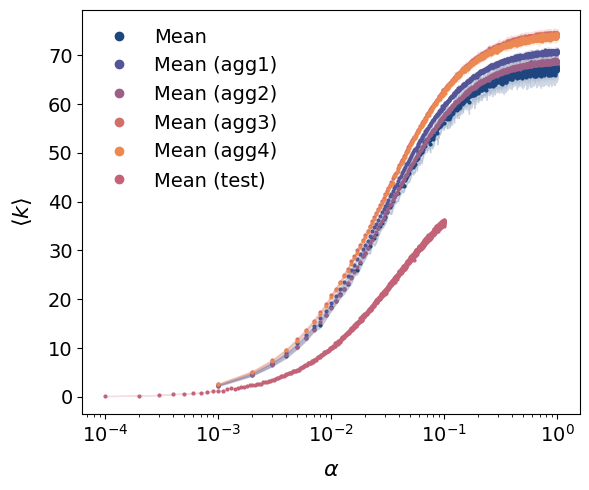

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data_random = np.loadtxt("mean_degree_over_runs.txt")
data_agg1 = np.loadtxt("mean_degree_over_runs_agg1.txt")
data_agg2 = np.loadtxt("mean_degree_over_runs_agg2.txt")
data_agg3 = np.loadtxt("mean_degree_over_runs_agg3.txt")
data_agg4 = np.loadtxt("mean_degree_over_runs_agg4.txt")
data_test = np.loadtxt("mean_degree_over_runs_test.txt")




alpha_random = data_random[:,0]
mean_degree_random = data_random[:,1]
std_degree_random = data_random[:,2]

alpha_agg1 = data_agg1[:,0]
mean_degree_agg1 = data_agg1[:,1]
std_degree_agg1 = data_agg1[:,2]

alpha_agg2 = data_agg2[:,0]
mean_degree_agg2 = data_agg2[:,1]
std_degree_agg2 = data_agg2[:,2]

alpha_agg3 = data_agg3[:,0]
mean_degree_agg3 = data_agg3[:,1]
std_degree_agg3 = data_agg3[:,2]

alpha_agg4 = data_agg4[:,0]
mean_degree_agg4 = data_agg4[:,1]
std_degree_agg4 = data_agg4[:,2]

alpha_test = data_test[:,0]
mean_degree_test = data_test[:,1]
std_degree_test = data_test[:,2]

plt.figure(figsize=(6,5))
plt.plot(alpha_random, mean_degree_random, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.0),label="Mean")
plt.fill_between(alpha_random, mean_degree_random-std_degree_random, mean_degree_random+std_degree_random, alpha=0.2, color=sunset2(0.0))

plt.plot(alpha_agg1, mean_degree_agg1, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.2), label="Mean (agg1)")
plt.fill_between(alpha_agg1, mean_degree_agg1-std_degree_agg1, mean_degree_agg1+std_degree_agg1, alpha=0.2, color=sunset2(0.2))

plt.plot(alpha_agg2, mean_degree_agg2, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.4), label="Mean (agg2)")
plt.fill_between(alpha_agg2, mean_degree_agg2-std_degree_agg2, mean_degree_agg2+std_degree_agg2, alpha=0.2, color=sunset2(0.4))

plt.plot(alpha_agg3, mean_degree_agg3, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.6), label="Mean (agg3)")
plt.fill_between(alpha_agg3, mean_degree_agg3-std_degree_agg3, mean_degree_agg3+std_degree_agg3, alpha=0.2, color=sunset2(0.6))

plt.plot(alpha_agg4, mean_degree_agg4, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.8), label="Mean (agg4)")
plt.fill_between(alpha_agg4, mean_degree_agg4-std_degree_agg4, mean_degree_agg4+std_degree_agg4, alpha=0.2, color=sunset2(0.8))

plt.plot(alpha_test, mean_degree_test, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.5), label="Mean (test)")
plt.fill_between(alpha_test, mean_degree_test-std_degree_test, mean_degree_test+std_degree_test, alpha=0.2, color=sunset2(0.5))


plt.xlabel(r'$\alpha$', fontsize=16, labelpad=10)
plt.ylabel(r'$\langle k\rangle$', fontsize=16, labelpad=10)
plt.xscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.legend(loc = 'best', frameon = False, fontsize = 14, markerscale = 3)
plt.show()

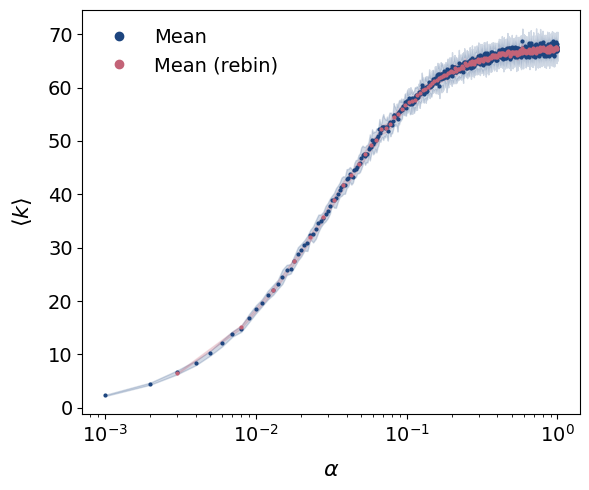

In [21]:
import numpy as np

def rebin_data(filename, block_size, output=None):

    # cargar datos
    data = np.loadtxt(filename)
    alpha = data[:,0]
    value = data[:,1]
    sigma = data[:,2]

    N = len(alpha)
    n_blocks = N // block_size

    alpha_new = np.zeros(n_blocks)
    value_new = np.zeros(n_blocks)
    sigma_new = np.zeros(n_blocks)

    for i in range(n_blocks):

        start = i * block_size
        end = start + block_size

        alpha_block = alpha[start:end]
        value_block = value[start:end]
        sigma_block = sigma[start:end]

        # promedio
        alpha_new[i] = np.mean(alpha_block)
        value_new[i] = np.mean(value_block)

        # propagación del error
        sigma_new[i] = np.sqrt(np.sum(sigma_block**2)) / block_size

    # guardar si se pide
    if output is not None:
        np.savetxt(
            output,
            np.column_stack((alpha_new, value_new, sigma_new)),
            header="alpha value sigma"
        )

    return alpha_new, value_new, sigma_new


alpha_new, value_new, sigma_new = rebin_data(
    "mean_degree_over_runs.txt",
    block_size=5,
    output=None
)

def rebin_data_weighted(filename, block_size, output=None):

    data = np.loadtxt(filename)

    alpha = data[:,0]
    value = data[:,1]
    sigma = data[:,2]

    N = len(alpha)
    n_blocks = N // block_size

    alpha_new = np.zeros(n_blocks)
    value_new = np.zeros(n_blocks)
    sigma_new = np.zeros(n_blocks)

    for i in range(n_blocks):

        start = i*block_size
        end = start + block_size

        a = alpha[start:end]
        x = value[start:end]
        s = sigma[start:end]

        w = 1.0 / (s**2)

        alpha_new[i] = np.mean(a)

        value_new[i] = np.sum(w*x) / np.sum(w)

        sigma_new[i] = 1.0 / np.sqrt(np.sum(w))

    if output:
        np.savetxt(output,
                   np.column_stack((alpha_new, value_new, sigma_new)),
                   header="alpha value sigma")

    return alpha_new, value_new, sigma_new

import matplotlib.pyplot as plt

alpha_weieghted, value_weighted, sigma_weighted = rebin_data_weighted(
    "mean_degree_over_runs.txt",
    block_size=5,
    output=None
)


data_random = np.loadtxt("mean_degree_over_runs.txt")

alpha_random = data_random[:,0]
mean_degree_random = data_random[:,1]
std_degree_random = data_random[:,2]

plt.figure(figsize=(6,5))
plt.plot(alpha_random, mean_degree_random, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.0),label="Mean")
plt.fill_between(alpha_random, mean_degree_random-std_degree_random, mean_degree_random+std_degree_random, alpha=0.2, color=sunset2(0.0))

plt.plot(alpha_new, value_new, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.5), label="Mean (rebin)")
plt.fill_between(alpha_new, value_new-sigma_new, value_new+sigma_new, alpha=0.2, color=sunset2(0.5))

plt.xlabel(r'$\alpha$', fontsize=16, labelpad=10)
plt.ylabel(r'$\langle k\rangle$', fontsize=16, labelpad=10)
plt.xscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.legend(loc = 'best', frameon = False, fontsize = 14, markerscale = 3)
plt.show()




# Tune aggregation

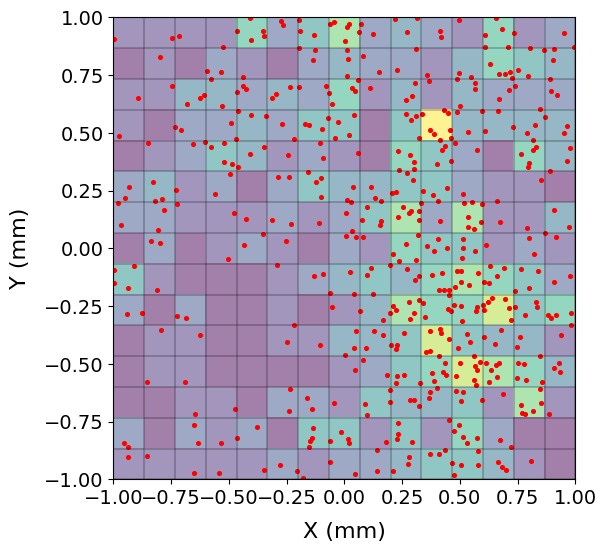

[[1. 2. 0. 0. 0. 2. 4. 0. 2. 2. 0. 1. 1. 0. 1.]
 [1. 0. 0. 1. 1. 0. 1. 2. 2. 3. 1. 0. 1. 1. 1.]
 [1. 2. 1. 1. 1. 2. 0. 0. 1. 1. 2. 2. 3. 0. 1.]
 [1. 1. 1. 0. 0. 0. 0. 1. 1. 2. 4. 2. 3. 2. 1.]
 [1. 2. 0. 0. 0. 0. 0. 2. 1. 0. 3. 3. 2. 1. 5.]
 [2. 0. 2. 0. 1. 1. 1. 1. 2. 2. 1. 2. 3. 0. 2.]
 [1. 4. 2. 0. 1. 0. 2. 0. 1. 4. 2. 4. 2. 2. 4.]
 [2. 4. 1. 1. 3. 1. 3. 2. 2. 3. 1. 4. 5. 3. 6.]
 [2. 1. 4. 2. 3. 3. 4. 1. 4. 3. 0. 0. 1. 2. 2.]
 [3. 4. 3. 4. 4. 6. 3. 5. 6. 4. 5. 4. 3. 2. 3.]
 [4. 1. 3. 5. 7. 5. 5. 4. 2. 4. 4. 8. 1. 1. 2.]
 [4. 5. 4. 7. 4. 5. 6. 4. 6. 2. 2. 3. 3. 3. 1.]
 [3. 2. 1. 6. 3. 7. 5. 1. 1. 1. 0. 3. 2. 5. 5.]
 [1. 0. 6. 5. 3. 4. 4. 2. 1. 1. 5. 3. 2. 4. 1.]
 [0. 0. 1. 3. 1. 5. 2. 1. 3. 0. 3. 3. 2. 3. 2.]]


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pypalettes import load_cmap 
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

filename = 'configurations/neurons_params_agg_nc25_s0.25.txt'

def load_neuron_params(filename):
    data = np.loadtxt(filename, skiprows=1)
    return data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]

X, Y, Soma_Diameter, Dendrite_Diameter, Axon_Length = load_neuron_params(filename)
L = 2 # (mm)
plt.figure(figsize=(6,6))
plt.scatter(X, Y, s=7, color='red')
plt.xlabel('X (mm)', fontsize=16, labelpad=10)
plt.ylabel('Y (mm)', fontsize=16, labelpad=10)
plt.xlim(-L/2, L/2)
plt.ylim(-L/2, L/2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

xmin = ymin = -L/2
xmax = ymax = L/2

n_grid  = 15

x_grid = np.linspace(xmin, xmax, n_grid+1) 
y_grid = np.linspace(ymin, ymax, n_grid+1)

for x in x_grid:
    plt.axvline(x, color='black', linestyle='-', lw=0.3)
for y in y_grid:
    plt.axhline(y, color='black', linestyle='-', lw=0.3)

H, _, _ = np.histogram2d(X,Y, bins = n_grid, range=[[xmin,xmax],[ymin,ymax]]) # H devuelve ordenado de forma (x,y)
plt.imshow(H.T, extent=[xmin,xmax,ymin,ymax], origin='lower', aspect = 'equal', alpha=0.5) # imshow espera (y,x) por lo que ploteo H.T y ya esta

plt.show()

print(H)

Gini coefficient: 0.3727130864197531


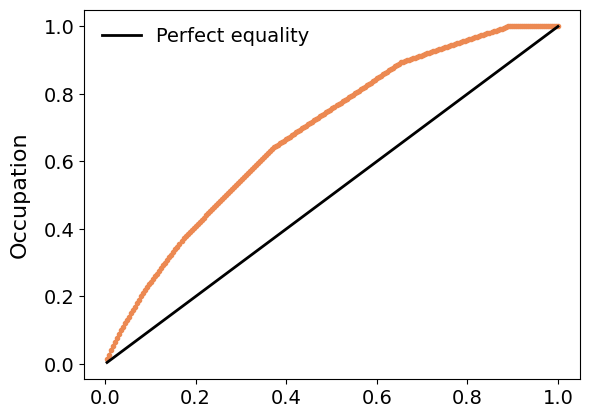

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pypalettes import load_cmap 
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

filename = 'configurations/neurons_params_random_l0.50.txt'


def load_neuron_params(filename):
    data = np.loadtxt(filename, skiprows=1)
    return data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]

X, Y, Soma_Diameter, Dendrite_Diameter, Axon_Length = load_neuron_params(filename)
L = 2 # (mm)
H, _, _ = np.histogram2d(X,Y, bins = n_grid, range=[[xmin,xmax],[ymin,ymax]]) # H devuelve ordenado de forma (x,y)

bin_sum = H.sum()
# print("Total neurons:", bin_sum)

sum_gini = 0.0
G = np.zeros(len(H.flatten()), dtype=np.float64)

H_flat = H.flatten()
H_flat.sort()
H_flat = H_flat[::-1]  # invierte el array para ordenar de mayor a menor
for i, h in enumerate(H_flat):
    sum_gini += h
    G[i] = sum_gini/bin_sum

ngrid = 15
bins = np.arange(1, ngrid*ngrid+1)
bins = bins/(ngrid*ngrid)

area_between = np.trapezoid(G-bins, bins)
Gini = 2*area_between
print("Gini coefficient:", Gini)

# print("Bins:", bins)
plt.plot(bins, G, color=sunset2(0.8), marker='o', markersize=3, linestyle='-', lw=1)
plt.plot(bins,bins, color='black', linestyle='-', lw=2, label="Perfect equality")
plt.legend(fontsize=14, loc='best', frameon=False)
plt.xlabel('', fontsize=16, labelpad=10)
plt.ylabel('Occupation', fontsize=16, labelpad=10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Gini coefficient: 0.6197491358024692


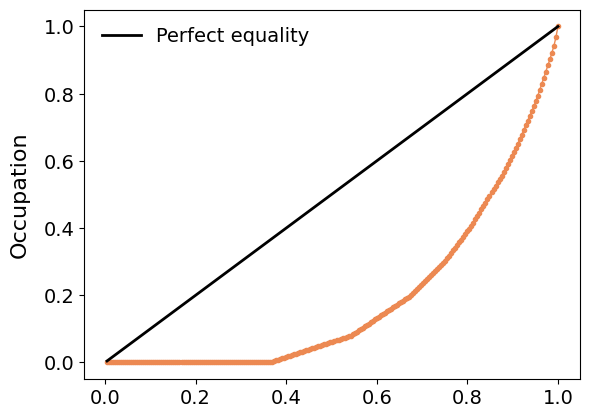

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pypalettes import load_cmap 
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

filename = 'configurations/neurons_params_agg_nc25_s0.10.txt'

def load_neuron_params(filename):
    data = np.loadtxt(filename, skiprows=1)
    return data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]

X, Y, Soma_Diameter, Dendrite_Diameter, Axon_Length = load_neuron_params(filename)
L = 2 # (mm)
H, _, _ = np.histogram2d(X,Y, bins = n_grid, range=[[xmin,xmax],[ymin,ymax]]) # H devuelve ordenado de forma (x,y)

bin_sum = H.sum()
# print("Total neurons:", bin_sum)

sum_gini = 0.0
G = np.zeros(len(H.flatten()), dtype=np.float64)

H_flat = H.flatten()
H_flat.sort()
for i, h in enumerate(H_flat):
    sum_gini += h
    G[i] = sum_gini/bin_sum

ngrid = 15
bins = np.arange(1, ngrid*ngrid+1)
bins = bins/(ngrid*ngrid)

area_between = np.trapezoid(bins-G, bins)
Gini = 2*area_between
print("Gini coefficient:", Gini)

# print("Bins:", bins)
plt.plot(bins, G, color=sunset2(0.8), marker='o', markersize=3, linestyle='-', lw=1)
plt.plot(bins,bins, color='black', linestyle='-', lw=2, label = "Perfect equality")
plt.legend(fontsize=14, loc='best', frameon=False)
plt.xlabel('', fontsize=16, labelpad=10)
plt.ylabel('Occupation', fontsize=16, labelpad=10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [148]:
def load_A_for_alpha(alpha, folder="run0_txt"):
    fname = f"adjacency_test_a{alpha:0.3f}.txt"
    path = os.path.join(folder, fname)
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

import os

alpha = 0.0001

A = load_A_for_alpha(alpha, folder="test_run000_txt")
print(A.shape)

np.fill_diagonal(A, 0)

(500, 500)


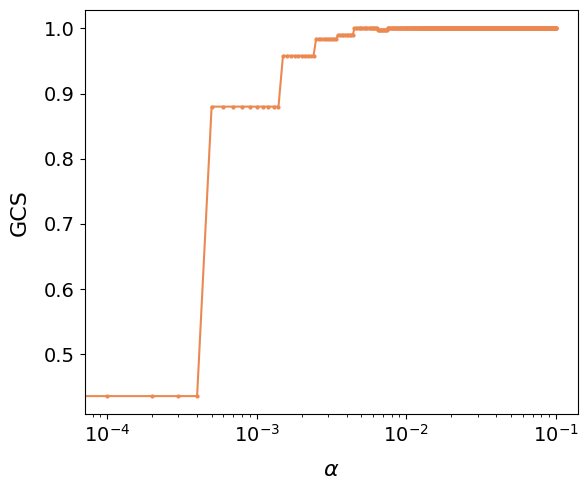

In [152]:
# Source - https://stackoverflow.com/a/62838497
# Posted by Rakesh Chintha
# Retrieved 2026-02-13, License - CC BY-SA 4.0

alpha = np.arange(0, 0.1, 0.00010)
GCS = []
N = 500

for a in alpha:
    A = load_A_for_alpha(a, folder="test_run000_txt")
    A = nx.from_numpy_array(A, create_using=nx.Graph)
    Acc = sorted(nx.connected_components(A), key=len, reverse=True)
    GCS.append(len(Acc[0]) / N)

# A = nx.from_numpy_array(A, create_using=nx.Graph)
# N = 500

# Acc = sorted(nx.connected_components(A), key=len, reverse=True)
# Agc = A.subgraph(Acc[0])
# GCS = len(Acc[0]) / N
# print("GCS:", GCS)

plt.figure(figsize=(6,5))
plt.plot(alpha, GCS, marker='o', markersize=2, linestyle='-', color=sunset2(0.8))
plt.xlabel(r'$\alpha$', fontsize=16, labelpad=10)
plt.ylabel('GCS', fontsize=16, labelpad=10)
plt.xscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()
